# Chapter 10
# Image Classification and Object Detection

---

## **Part I: Image Classification**

### With Vision Transformer (ViT)

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

C:\Users\sandi\anaconda3\envs\torch-gpu\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\sandi\.cache\huggingface\hub\models--google--vit-base-patch16-224. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Predicted Class: Egyptian cat


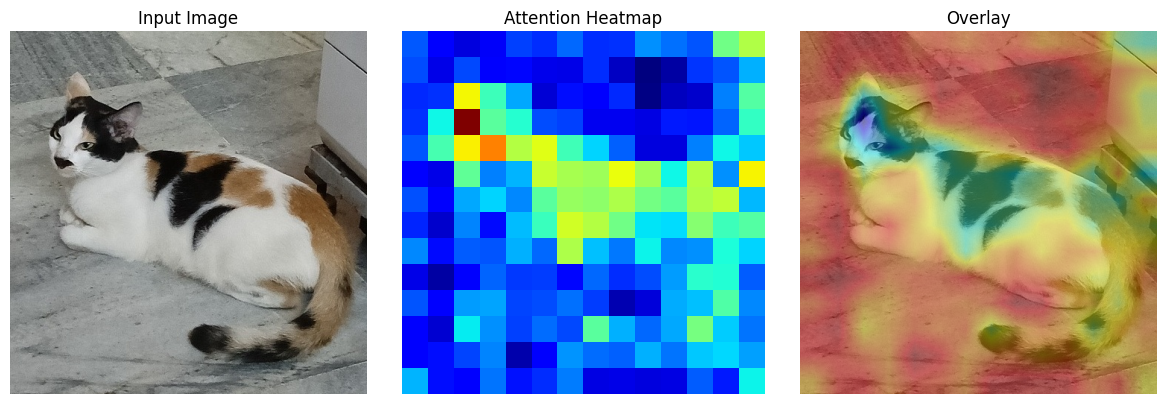

In [1]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from transformers import ViTImageProcessor, ViTForImageClassification

model_name = "google/vit-base-patch16-224"

processor = ViTImageProcessor.from_pretrained(model_name)
model = ViTForImageClassification.from_pretrained(
    model_name,
    output_attentions=True
)

model.eval()

# Load image
image_path = "images/cat.jpg"
image = Image.open(image_path).convert("RGB")
inputs = processor(images=image, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs, output_attentions=True)

logits = outputs.logits
attentions = outputs.attentions   # tuple: (layers, batch, heads, tokens, tokens)

# -----------------------------
# 1. Get CLS attention rollout
# -----------------------------
def rollout_attention(attentions):
    # attentions: list of layers
    result = torch.eye(attentions[0].shape[-1])

    for attn in attentions:
        attn_heads_fused = attn.mean(dim=1)[0]  # average heads
        attn_heads_fused += torch.eye(attn_heads_fused.shape[-1])  # residual
        attn_heads_fused /= attn_heads_fused.sum(dim=-1, keepdim=True)

        result = torch.matmul(attn_heads_fused, result)

    # CLS token is index 0
    mask = result[0, 1:]
    return mask

mask = rollout_attention(attentions)

# -----------------------------
# 2. Reshape to patch grid
# -----------------------------
num_patches = mask.shape[0]
grid_size = int(np.sqrt(num_patches))

heatmap = mask.reshape(grid_size, grid_size).cpu().numpy()

# Normalize
heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())

# -----------------------------
# 3. Resize heatmap to image
# -----------------------------
img = np.array(image)
heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

heatmap_color = cv2.applyColorMap(
    np.uint8(255 * heatmap_resized),
    cv2.COLORMAP_JET
)

overlay = cv2.addWeighted(img, 0.6, heatmap_color, 0.4, 0)

# -----------------------------
# 4. Prediction
# -----------------------------
pred_class = logits.argmax(-1).item()
label = model.config.id2label[pred_class]

print("Predicted Class:", label)

# -----------------------------
# 5. Show result
# -----------------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Input Image")
plt.imshow(image)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Attention Heatmap")
plt.imshow(heatmap, cmap="jet")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Overlay")
plt.imshow(overlay)
plt.axis("off")

plt.tight_layout()
plt.show()

### **with Swin Transformer**

In [ ]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from transformers import AutoImageProcessor, SwinForImageClassification

# -----------------------------
# Load Swin Transformer
# -----------------------------
model_name = "microsoft/swin-base-patch4-window7-224"

processor = AutoImageProcessor.from_pretrained(model_name)
model = SwinForImageClassification.from_pretrained(model_name)

model.eval()

# -----------------------------
# Load image
# -----------------------------
image_path = "images/parrot.png"
image = Image.open(image_path).convert("RGB")

inputs = processor(images=image, return_tensors="pt")

# Enable gradients for saliency
inputs["pixel_values"].requires_grad = True

# -----------------------------
# Forward pass
# -----------------------------
outputs = model(**inputs)
logits = outputs.logits

pred_class = logits.argmax(dim=-1).item()
score = logits[0, pred_class]

print("Predicted Class:", model.config.id2label[pred_class])

# -----------------------------
# Backprop for saliency
# -----------------------------
model.zero_grad()
score.backward()

grads = inputs["pixel_values"].grad  # (1, 3, H, W)

# Convert gradients → importance map
saliency = grads.abs().mean(dim=1)[0].detach().numpy()

# Normalize
saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)

# -----------------------------
# Resize heatmap to image size
# -----------------------------
img = np.array(image)

heatmap = cv2.resize(saliency, (img.shape[1], img.shape[0]))

heatmap_color = cv2.applyColorMap(
    np.uint8(255 * heatmap),
    cv2.COLORMAP_JET
)

overlay = cv2.addWeighted(img, 0.6, heatmap_color, 0.4, 0)

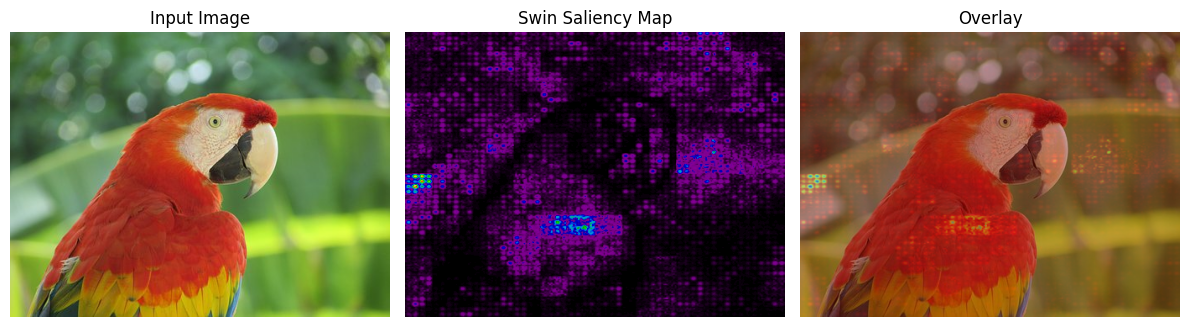

In [9]:
# -----------------------------
# Visualization
# -----------------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Input Image")
plt.imshow(image)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Swin Saliency Map")
plt.imshow(heatmap, cmap="nipy_spectral")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Overlay")
plt.imshow(overlay)
plt.axis("off")

plt.tight_layout()
plt.show()

## **Part II: Object Detection**

---

### **with RetinaNet**

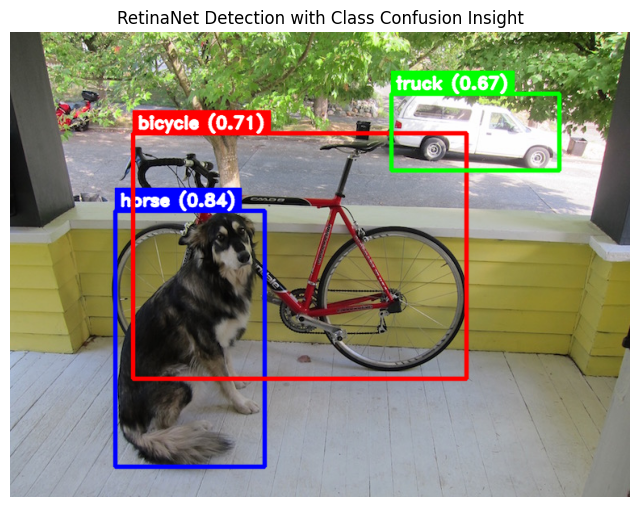

In [25]:
import torch
import torchvision
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

# -----------------------------
# Load RetinaNet
# -----------------------------
model = torchvision.models.detection.retinanet_resnet50_fpn(weights="DEFAULT")
model.eval()

# -----------------------------
# COCO Classes
# -----------------------------
COCO_CLASSES = [
    "__background__", "person", "bicycle", "car", "motorcycle", "airplane",
    "bus", "train", "truck", "boat", "traffic light", "fire hydrant",
    "stop sign", "parking meter", "bench", "bird", "cat", "dog", "horse",
    "sheep", "cow", "elephant", "bear", "zebra", "giraffe", "backpack",
    "umbrella", "handbag", "tie", "suitcase", "frisbee", "skis",
    "snowboard", "sports ball", "kite", "baseball bat", "baseball glove",
    "skateboard", "surfboard", "tennis racket", "bottle", "wine glass",
    "cup", "fork", "knife", "spoon", "bowl", "banana", "apple",
    "sandwich", "orange", "broccoli", "carrot", "hot dog", "pizza",
    "donut", "cake", "chair", "couch", "potted plant", "bed",
    "dining table", "toilet", "tv", "laptop", "mouse", "remote",
    "keyboard", "cell phone", "microwave", "oven", "toaster",
    "sink", "refrigerator", "book", "clock", "vase", "scissors",
    "teddy bear", "hair drier", "toothbrush"
]

# -----------------------------
# Vibrant Colors (HSV)
# -----------------------------
def generate_colors(n):
    colors = []
    for i in range(n):
        hue = int(180 * i / n)
        hsv = np.uint8([[[hue, 255, 255]]])
        rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)[0][0]
        colors.append(rgb.tolist())
    return colors

# -----------------------------
# Load Image
# -----------------------------
image_path = "images/dog_cycle.jpg"
image = Image.open(image_path).convert("RGB")

transform = transforms.Compose([transforms.ToTensor()])
img_tensor = transform(image)

# -----------------------------
# Inference
# -----------------------------
with torch.no_grad():
    outputs = model([img_tensor])[0]

boxes = outputs["boxes"]
scores = outputs["scores"]
labels = outputs["labels"]

# -----------------------------
# Filter detections
# -----------------------------
threshold = 0.6
keep = scores >= threshold

boxes = boxes[keep]
scores = scores[keep]
labels = labels[keep]

# -----------------------------
# Assign colors per detected class
# -----------------------------
unique_labels = sorted(set(labels.cpu().numpy().tolist()))
colors = generate_colors(len(unique_labels))
COLOR_MAP = {cls: color for cls, color in zip(unique_labels, colors)}

# -----------------------------
# Visualization
# -----------------------------
img = np.array(image).copy()

for box, score, label in zip(boxes, scores, labels):

    label_id = int(label)  # 🔑 FIX

    x1, y1, x2, y2 = map(int, box.tolist())
    class_name = COCO_CLASSES[label_id]
    color = COLOR_MAP[label_id]

    # Draw box
    cv2.rectangle(img, (x1, y1), (x2, y2), color, 3, lineType=cv2.LINE_AA)

    text = f"{class_name} ({score:.2f})"

    font = cv2.FONT_HERSHEY_DUPLEX
    font_scale = 0.7
    thickness = 2
    pad = 6

    (w, h), _ = cv2.getTextSize(text, font, font_scale, thickness)

    cv2.rectangle(img,
                  (x1, y1 - h - 2*pad),
                  (x1 + w + 2*pad, y1),
                  color, -1, lineType=cv2.LINE_AA)

    cv2.putText(img, text,
                (x1 + pad, y1 - pad),
                font, font_scale,
                (255, 255, 255),
                thickness,
                lineType=cv2.LINE_AA)

# -----------------------------
# Show Result
# -----------------------------
plt.figure(figsize=(8, 8))
plt.imshow(img.astype(np.uint8))
plt.title("RetinaNet Detection with Class Confusion Insight")
plt.axis("off")
plt.show()

### **with Mask R-CNN**

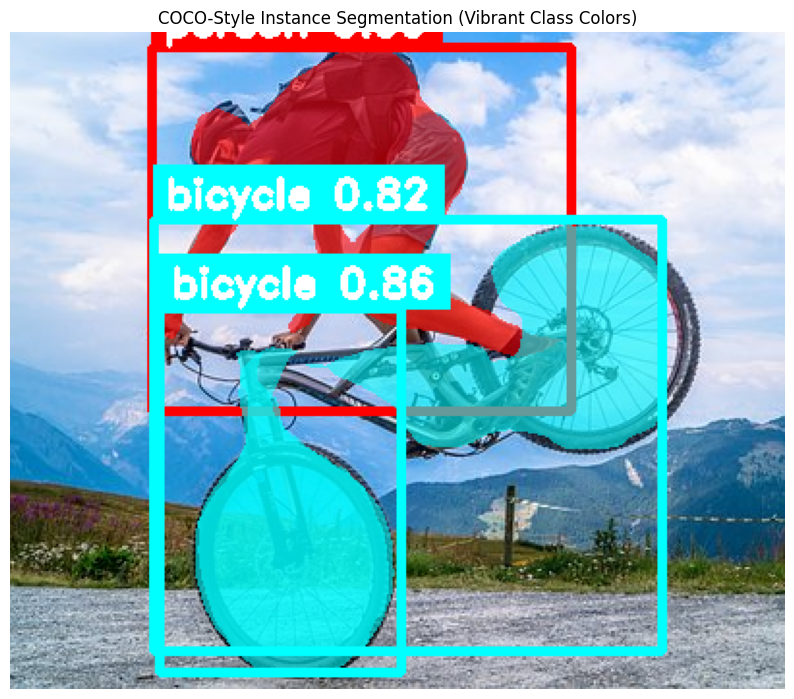

In [22]:
import torch
import torchvision
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

# -----------------------------
# Load Mask R-CNN model
# -----------------------------
model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")
model.eval()

# -----------------------------
# COCO class labels
# -----------------------------
COCO_CLASSES = [
    "__background__", "person", "bicycle", "car", "motorcycle", "airplane",
    "bus", "train", "truck", "boat", "traffic light", "fire hydrant",
    "stop sign", "parking meter", "bench", "bird", "cat", "dog", "horse",
    "sheep", "cow", "elephant", "bear", "zebra", "giraffe", "backpack",
    "umbrella", "handbag", "tie", "suitcase", "frisbee", "skis",
    "snowboard", "sports ball", "kite", "baseball bat", "baseball glove",
    "skateboard", "surfboard", "tennis racket", "bottle", "wine glass",
    "cup", "fork", "knife", "spoon", "bowl", "banana", "apple",
    "sandwich", "orange", "broccoli", "carrot", "hot dog", "pizza",
    "donut", "cake", "chair", "couch", "potted plant", "bed",
    "dining table", "toilet", "tv", "laptop", "mouse", "remote",
    "keyboard", "cell phone", "microwave", "oven", "toaster",
    "sink", "refrigerator", "book", "clock", "vase", "scissors",
    "teddy bear", "hair drier", "toothbrush"
]

# -----------------------------
# Generate vibrant colors (HSV)
# -----------------------------
def generate_vibrant_colors(n):
    colors = []
    for i in range(n):
        hue = int(180 * i / n)
        hsv = np.uint8([[[hue, 255, 255]]])
        rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)[0][0]
        colors.append(rgb.tolist())
    return colors

# -----------------------------
# Load image
# -----------------------------
image_path = "images/cycle.jpg"  # change this
image = Image.open(image_path).convert("RGB")

transform = transforms.Compose([transforms.ToTensor()])
img_tensor = transform(image)

# -----------------------------
# Inference
# -----------------------------
with torch.no_grad():
    outputs = model([img_tensor])[0]

boxes = outputs["boxes"].cpu().numpy()
scores = outputs["scores"].cpu().numpy()
labels = outputs["labels"].cpu().numpy()
masks = outputs["masks"].cpu().numpy()

# -----------------------------
# Filter detections
# -----------------------------
threshold = 0.5
keep = scores >= threshold

boxes = boxes[keep]
scores = scores[keep]
labels = labels[keep]
masks = masks[keep]

# -----------------------------
# Assign colors ONLY to detected classes
# -----------------------------
unique_labels = sorted(set(labels.tolist()))
colors = generate_vibrant_colors(len(unique_labels))
COLOR_MAP = {cls: color for cls, color in zip(unique_labels, colors)}

# -----------------------------
# Visualization
# -----------------------------
img = np.array(image).copy()

for box, score, label, mask in zip(boxes, scores, labels, masks):

    x1, y1, x2, y2 = map(int, box)
    class_name = COCO_CLASSES[label]
    color = COLOR_MAP[label]

    # ---- Mask ----
    mask = (mask[0] > 0.6).astype(np.uint8)
    mask = cv2.resize(mask, (img.shape[1], img.shape[0]))

    colored_mask = np.zeros_like(img)
    colored_mask[:] = color

    alpha = 0.6
    img = np.where(mask[:, :, None],
                   img * (1 - alpha) + colored_mask * alpha,
                   img)

    # ---- Bounding Box ----
    cv2.rectangle(img, (x1, y1), (x2, y2), color, 3, lineType=cv2.LINE_AA)

    # ---- Label ----
    text = f"{class_name} {score:.2f}"

    font = cv2.FONT_HERSHEY_DUPLEX
    font_scale = 0.7
    thickness = 2
    pad = 6

    (w, h), _ = cv2.getTextSize(text, font, font_scale, thickness)

    # Background box
    cv2.rectangle(
        img,
        (x1, y1 - h - 2 * pad),
        (x1 + w + 2 * pad, y1),
        color,
        -1,
        lineType=cv2.LINE_AA
    )

    # Text
    cv2.putText(
        img,
        text,
        (x1 + pad, y1 - pad),
        font,
        font_scale,
        (255, 255, 255),
        thickness,
        lineType=cv2.LINE_AA
    )

# -----------------------------
# Display
# -----------------------------
plt.figure(figsize=(10, 10))
plt.imshow(img.astype(np.uint8))
plt.title("COCO-Style Instance Segmentation (Vibrant Class Colors)")
plt.axis("off")
plt.show()